In [1]:
from utils import FLOWSql

#### Set the FLOWS_API_KEY variable appropriately,
#### this hack may not work unless FLOWS_API_KEY is set in the bash environment ####
FLOWS_API_KEY=!bash -i -c 'echo $FLOWS_API_KEY'
FLOWS_API_KEY=FLOWS_API_KEY[-1]

In [2]:
# --- Config ---
Instrument='NOT'

color_bases = {
    'H_mag': ['J_mag', 'H_mag'],
    'J_mag': ['J_mag', 'H_mag'],
    'K_mag': ['H_mag', 'K_mag'],  # try with J - H
    'Y_mag': ['H_mag', 'K_mag'],  # Y need redefined
    'B_mag': ['B_mag', 'V_mag'],
    'V_mag': ['B_mag', 'V_mag'],
    'R_mag': ['B_mag', 'V_mag'],
    'u_mag': ['u_mag', 'g_mag'],
    'g_mag': ['g_mag', 'r_mag'],
    'r_mag': ['g_mag', 'r_mag'],
    'i_mag': ['r_mag', 'i_mag'],
    'z_mag': ['i_mag', 'z_mag'],
}

basedir='/nerdrage/calc/archive/photometry/'


fsql = FLOWSql(FLOWS_API_KEY)
result = fsql.query("""SELECT f.path, f.photfilter, t.target_name, s.sitename
FROM files f
JOIN targets t ON f.targetid = t.targetid
JOIN sites s ON f.site = s.siteid
WHERE f.datatype = 2
AND s.sitename = '"""+Instrument+"""'
AND t.target_status = 'target' """)

filelist = [tuple(x.values()) for x in result['rows']]

#AND t.project = 'flows'

In [3]:
from itertools import groupby
import re

def get_highest_version_files(filelist):
    # Extract base name (without version) for grouping
    def base_key(entry):
        path = entry[0]
        # Remove version suffix to get base name
        base = re.sub(r'v\d+/photometry-.+', '', path)
        # Also normalize using filter and object name
        return (base, entry[1], entry[2])
    
    def version_num(entry):
        match = re.search(r'v(\d+)\.ecsv$', entry[0])
        return int(match.group(1)) if match else 0
    
    # Group by base path, keep only max version
    from collections import defaultdict
    groups = defaultdict(list)
    for entry in filelist:
        groups[base_key(entry)].append(entry)
    
    return [max(group, key=version_num) for group in groups.values()]

highest = get_highest_version_files(filelist)
len(highest)

1187

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from collections import defaultdict
import re
from astropy.stats import SigmaClip, mad_std
import copy
import json
from datetime import datetime


filter_groups = defaultdict(list)
for filepath, filt, objname, sitename in highest:
    filt=filt[0:1]
    filter_groups[filt].append((filepath, objname))
filter_groups.keys()

dict_keys(['g', 'i', 'r', 'u', 'B', 'V', 'J', 'H', 'K', 'z', 'R'])

In [129]:
def color_fitter(X, Y, Xerr=None, Yerr=None, fitter='lin'):
    if fitter == 'linmix':
        from linmix.linmix import LinMix
        lm=LinMix(X, Y, Xerr, Yerr, parallelize=True, nchains=10)
        lm.run_mcmc(miniter=500, maxiter=5000, silent=True)

        slope, intercept = (np.median(lm.chain['beta']), np.median(lm.chain['alpha']))
        slope_error, intercept_error = (np.std(lm.chain['beta']), np.std(lm.chain['alpha']))
        return ([intercept,intercept_error], [slope,slope_error], np.poly1d([slope,intercept]), lm.chain)

    elif fitter == 'lin':
        if Xerr is not None:
            weights = 1.0 / (Yerr**2 + Xerr**2)
        else:
            weights = 1.0 / Yerr**2
        coeffs, cov = np.polyfit(X, Y, deg=1, w=weights, cov=True)
        slope, intercept = coeffs
        slope_error, intercept_error = np.sqrt(np.diag(cov))
        return ([intercept,intercept_error], [slope,slope_error], np.poly1d(coeffs), None)
    else:
        raise ValueError(f"Unknown fitter type: {fitter}")
  
        

No of files to read for filter g 93
Niter 8, -> Color term: [np.float64(0.10411574649739828), np.float64(0.0027670002478364557)]                         
  Converged after 8 iterations

Filter g:
  x-axis : g_mag - r_mag
  y-axis : instmag - g_mag
  color_term = 0.104122 ± 0.002450
  intercept  = 0.000271 ± 0.001827
  N stars    = 1670
  N clipped  = 146


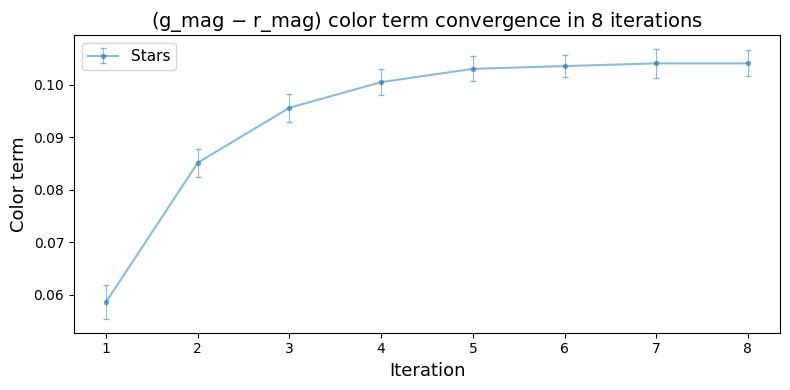

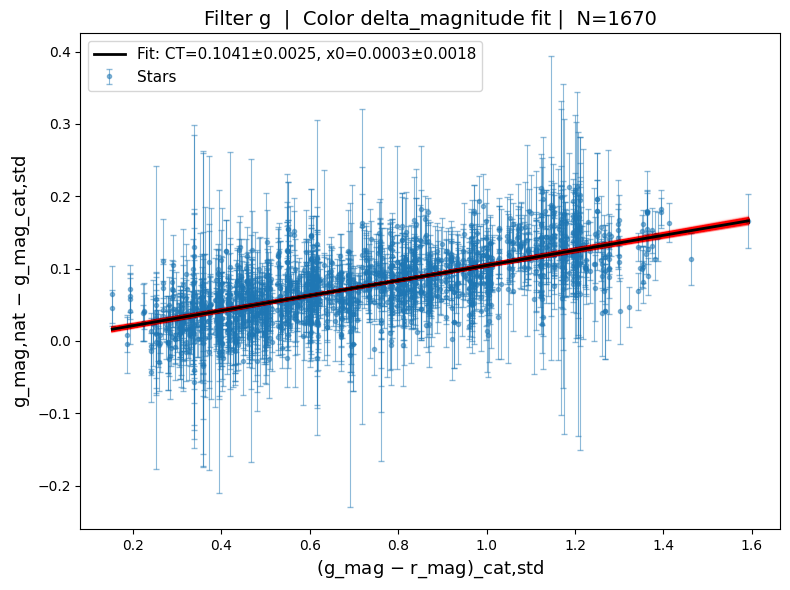

No of files to read for filter i 114
Niter 4, -> Color term: [np.float64(-0.06980909978512748), np.float64(0.002657380397374809)]                          
  Converged after 4 iterations

Filter i:
  x-axis : r_mag - i_mag
  y-axis : instmag - i_mag
  color_term = -0.069777 ± 0.002383
  intercept  = 0.002227 ± 0.001185
  N stars    = 2920
  N clipped  = 423


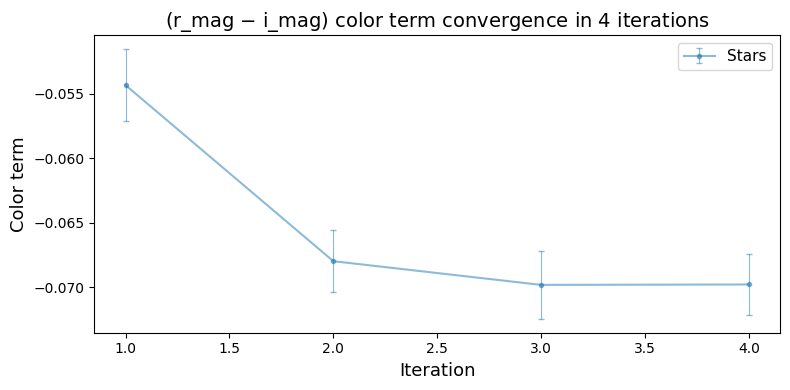

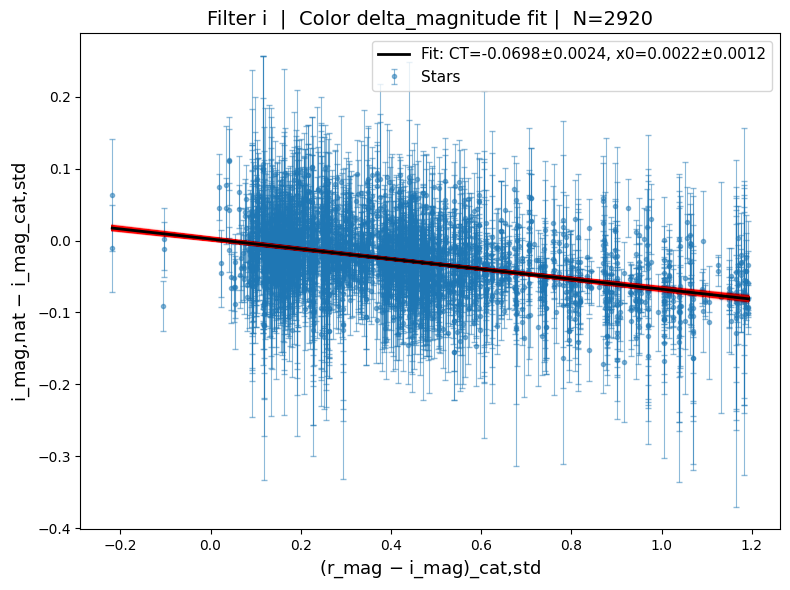

No of files to read for filter r 111
Niter 2, -> Color term: [np.float64(0.0013695433160395684), np.float64(0.001757696186669695)]                         
  Converged after 2 iterations

Filter r:
  x-axis : g_mag - r_mag
  y-axis : instmag - r_mag
  color_term = 0.001461 ± 0.001766
  intercept  = 0.001144 ± 0.001512
  N stars    = 2650
  N clipped  = 243


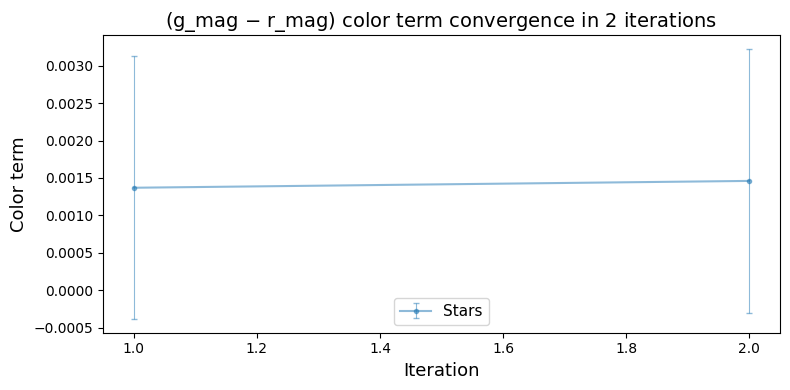

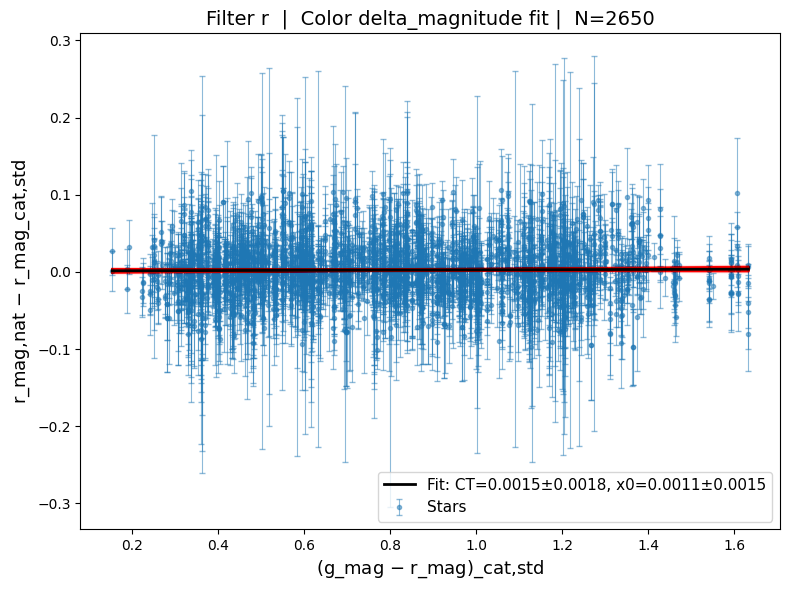

No of files to read for filter u 23


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



  Converged after 9 iterations

Filter u:
  x-axis : u_mag - g_mag
  y-axis : instmag - u_mag
  color_term = -0.047910 ± 0.010363
  intercept  = 0.002861 ± 0.016657
  N stars    = 109
  N clipped  = 8


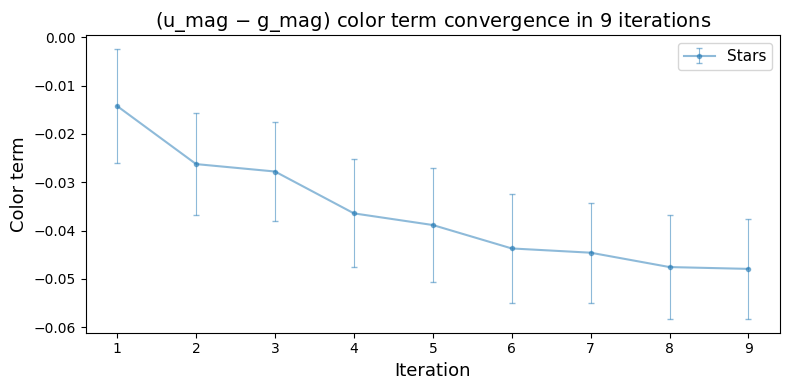

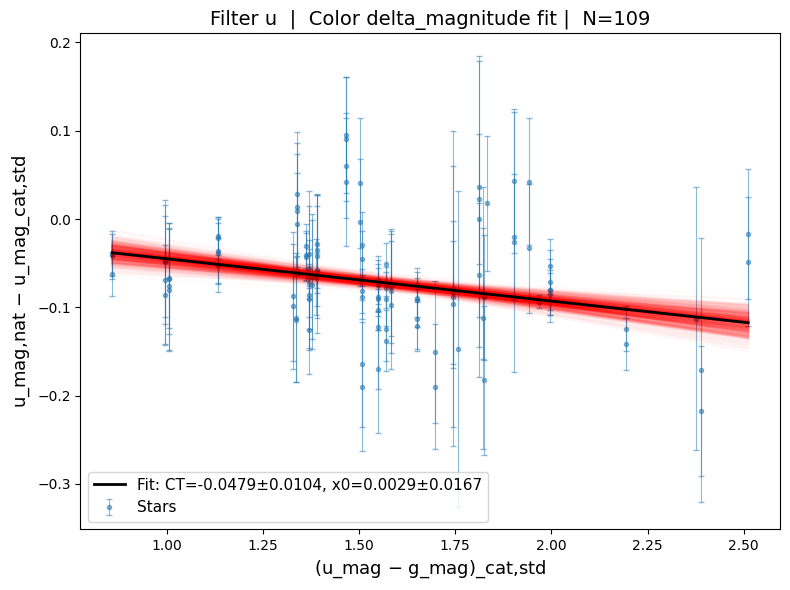

No of files to read for filter B 109
Niter 10, -> Color term: [np.float64(-0.04939584332768297), np.float64(0.009317602249523221)]                         
  Converged after 10 iterations

Filter B:
  x-axis : B_mag - V_mag
  y-axis : instmag - B_mag
  color_term = -0.049465 ± 0.008779
  intercept  = 0.001110 ± 0.006735
  N stars    = 908
  N clipped  = 151


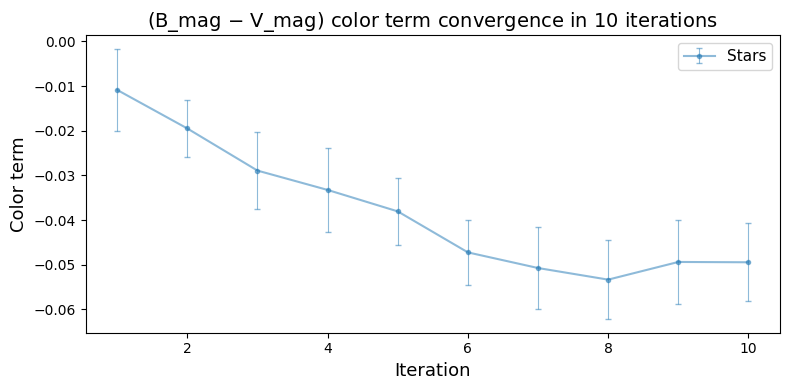

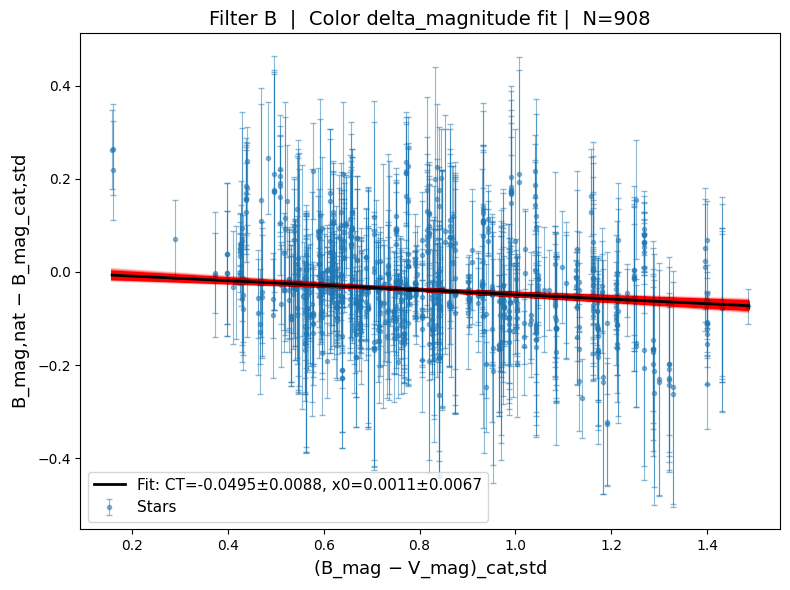

No of files to read for filter V 102
Niter 6, -> Color term: [np.float64(0.06664989882358777), np.float64(0.007800069646540262)]                         
  Converged after 6 iterations

Filter V:
  x-axis : B_mag - V_mag
  y-axis : instmag - V_mag
  color_term = 0.066346 ± 0.006799
  intercept  = 0.002298 ± 0.005308
  N stars    = 782
  N clipped  = 182


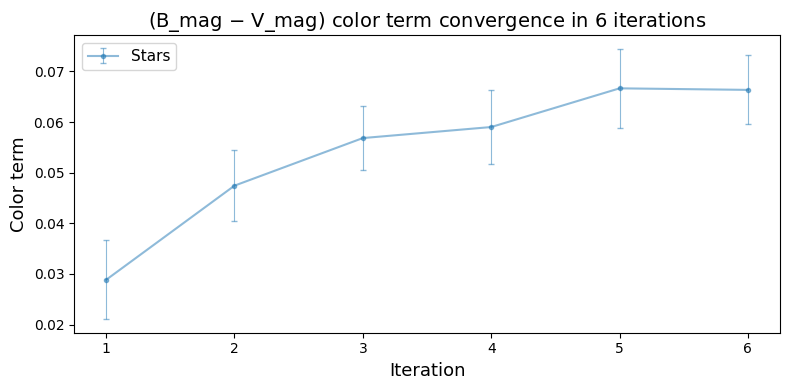

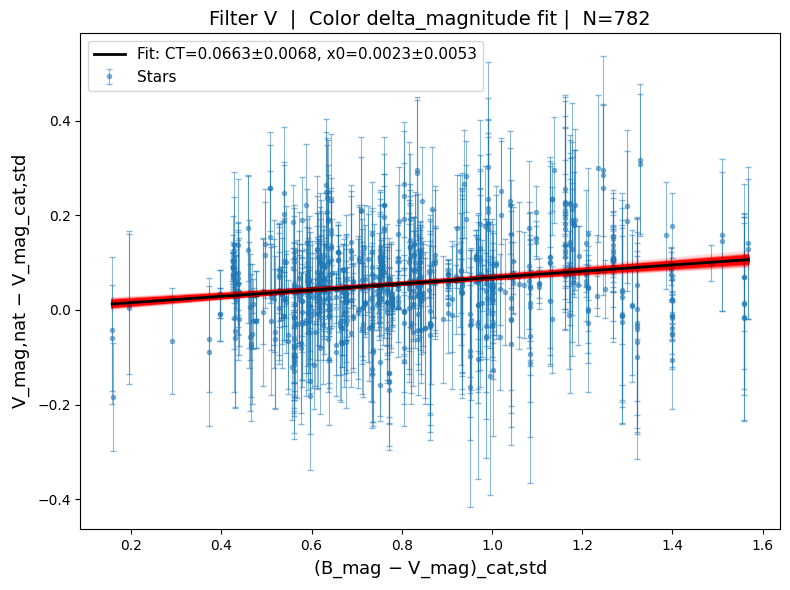

No of files to read for filter J 293
Niter 14, -> Color term: [np.float64(-0.18756203869113966), np.float64(0.005522493154450586)]                         
  Converged after 14 iterations

Filter J:
  x-axis : J_mag - H_mag
  y-axis : instmag - J_mag
  color_term = -0.187109 ± 0.005842
  intercept  = 0.003521 ± 0.003321
  N stars    = 6170
  N clipped  = 864


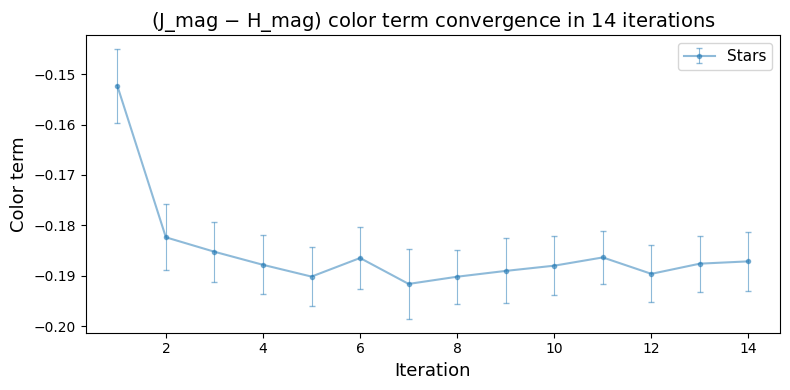

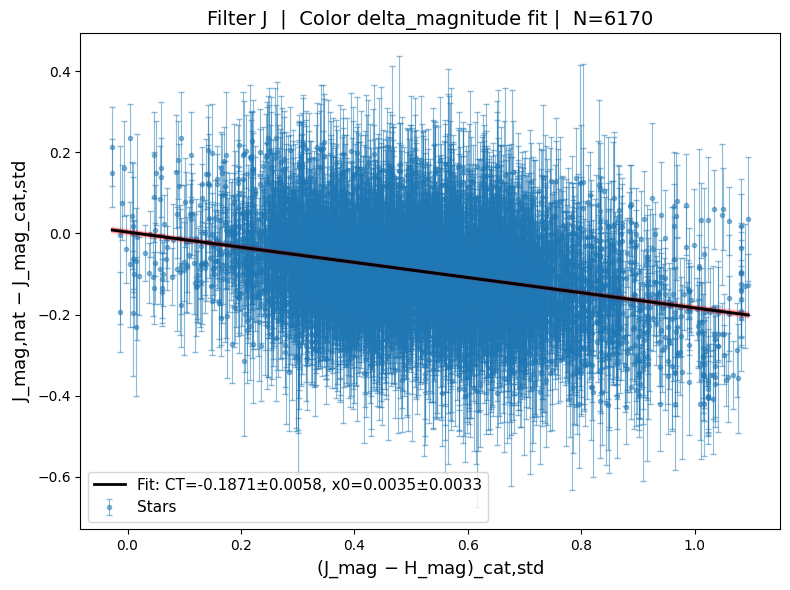

No of files to read for filter H 289
Niter 9, -> Color term: [np.float64(0.3146160514322881), np.float64(0.007245884251330667)]                          
  Converged after 9 iterations

Filter H:
  x-axis : J_mag - H_mag
  y-axis : instmag - H_mag
  color_term = 0.314284 ± 0.007735
  intercept  = 0.002109 ± 0.004232
  N stars    = 6173
  N clipped  = 926


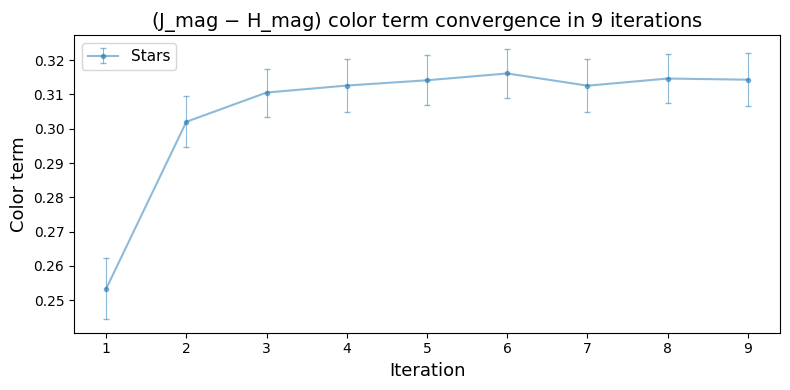

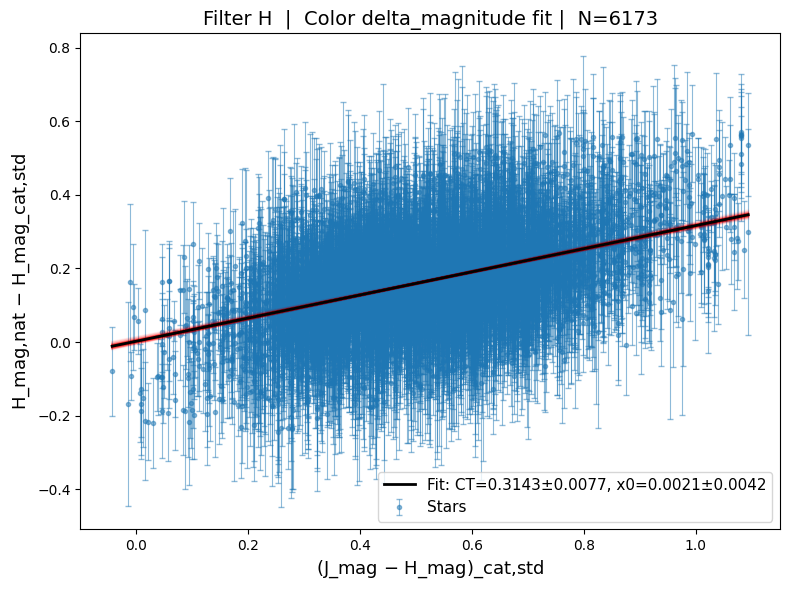

No of files to read for filter K 37
Niter 10, -> Color term: [np.float64(0.479351438455346), np.float64(0.02609352852473013)]                           
  Converged after 10 iterations

Filter K:
  x-axis : H_mag - K_mag
  y-axis : instmag - K_mag
  color_term = 0.479279 ± 0.026001
  intercept  = 0.009239 ± 0.006194
  N stars    = 1083
  N clipped  = 165


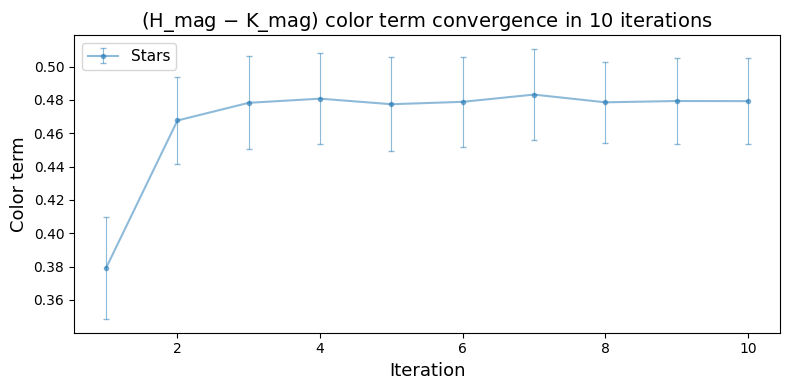

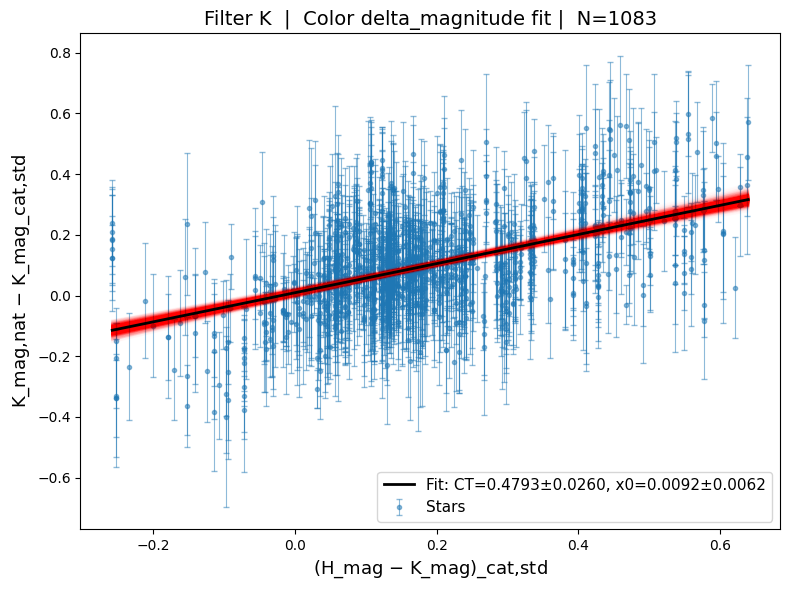

No of files to read for filter z 15
Niter 9, -> Color term: [np.float64(-0.12105080839717715), np.float64(0.009826421560064217)]                         
  Converged after 9 iterations

Filter z:
  x-axis : i_mag - z_mag
  y-axis : instmag - z_mag
  color_term = -0.121399 ± 0.007852
  intercept  = 0.002810 ± 0.001777
  N stars    = 578
  N clipped  = 72


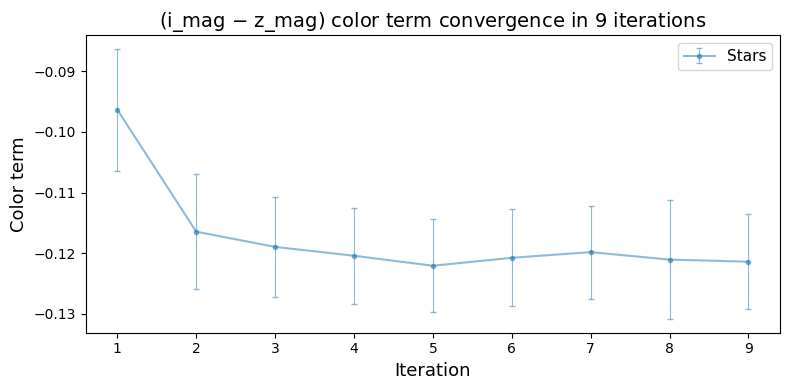

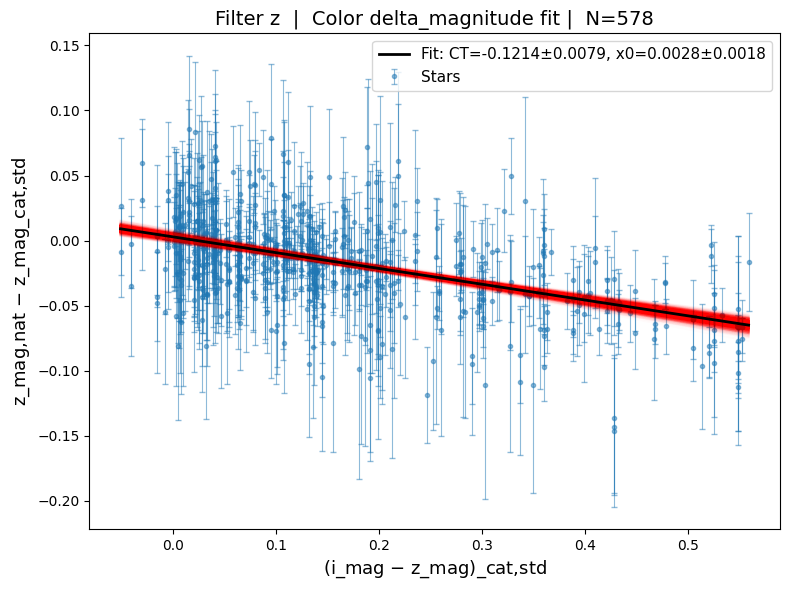

No of files to read for filter R 1
Skipping filter R: no color_bases entry for R_mag


In [131]:
for filt in list(filter_groups.keys()):
    file_entries=filter_groups[filt] 
    print("No of files to read for filter",filt,len(file_entries))
    mag_col = f'{filt}_mag'

    if mag_col not in color_bases:
        print(f"Skipping filter {filt}: no color_bases entry for {mag_col}")
        continue

    color_col0, color_col1 = color_bases[mag_col]  # e.g. ['J_mag', 'H_mag']

    all_color, all_Dmag, all_Dmag_err = [], [], []

    for filepath, objname in file_entries:
        try:
            t = Table.read(basedir + filepath, format='ascii.ecsv')
            t = t[t['starid']>0]  # skip SN mag

            # Required columns
            needed = ['flux_psf', 'flux_psf_error', 'mag', 'mag_error',
                      mag_col, color_col0, color_col1]
            if not all(col in t.colnames for col in needed):
                missing = [c for c in needed if c not in t.colnames]
                print(f"  Skipping {filepath}: missing columns {missing}")
                continue

            flux     = np.array(t['flux_psf'].data,        dtype=float)
            flux_err = np.array(t['flux_psf_error'].data,  dtype=float)
            mag      = np.array(t['mag'].data,             dtype=float)
            ref_mag  = np.array(t[mag_col].data,           dtype=float)
            col0     = np.array(t[color_col0].data,        dtype=float)
            col1     = np.array(t[color_col1].data,        dtype=float)

            # Mask out bad values
            valid = (flux > 0) & np.isfinite(flux) & np.isfinite(ref_mag) \
                  & np.isfinite(col0) & np.isfinite(col1) & (ref_mag !=0) & (col0 !=0) & (col1 !=0) & (col0 != col1)
            flux     = flux[valid];     flux_err = flux_err[valid]
            mag      = mag[valid];      ref_mag  = ref_mag[valid]
            col0     = col0[valid];     col1     = col1[valid]

            # Instrumental magnitude and error
            instmag       = -2.5 * np.log10(flux) + 24
            instmag_error = 2.5 * flux_err / flux / np.log(10)

            # Axes
            y = mag - ref_mag                  # instrumental - catalog mag
            x = col0 - col1                        # e.g. J_mag - H_mag

            if np.any(x==0):
                print(f"  x==0 for {basedir+filepath}")
                

            all_color.append(x)
            all_Dmag.append(y)
            all_Dmag_err.append(instmag_error)   # This is to ensure we use the photometry error only

        except Exception as e:
            print(f"  Error reading {filepath}: {e}")
            continue

    if not all_Dmag:
        print(f"No valid data for filter {filt}, skipping plot.")
        continue

    color_term=[[0, 0]]

    while True:
        if len(color_term) > 30:
            print(f"Niter {len(color_term)}, -> Color term: {color_term[-1]}                         ")
            if len(color_term) > 40:
                print("Warning!! Didn't converge")
                break
        else:
            print(f"Niter {len(color_term)}, -> Color term: {color_term[-1]}                         ",end='\r')
        CP_all_color=copy.deepcopy(all_color)
        CP_all_Dmag=copy.deepcopy(all_Dmag)
        CP_all_Dmag_err=copy.deepcopy(all_Dmag_err)

        ### Here we calculate ZP with CT correction applied for each data set in the list
        for i in range(len(CP_all_color)):
            tmp = CP_all_Dmag[i] - color_term[-1][0] * CP_all_color[i]
            sigclip = SigmaClip(sigma=3, maxiters=5)
            mask = ~sigclip(tmp).mask
            CP_all_Dmag[i] = CP_all_Dmag[i] - np.median(tmp[mask])
            CP_all_Dmag_err[i] = np.sqrt( CP_all_Dmag_err[i]**2 + (np.std(tmp[mask]))**2 )      # sigma= MAD*1.4826 
            #CP_all_color[i] = CP_all_color[i][mask]


        # Concatenate across all files for this filter
        X    = np.concatenate(CP_all_color)
        Y    = np.concatenate(CP_all_Dmag)
        Yerr = np.concatenate(CP_all_Dmag_err)

        # --- Linear fit (weighted by 1/err^2) ---
        # Mask out any non-finite values or zero/negative errors
        fit_mask = (np.isfinite(X) & np.isfinite(Y) & np.isfinite(Yerr) & (Yerr > 0) & (Yerr <.3))


        if fit_mask.sum() < 2:
            print(f"  Not enough valid points to fit for filter {filt}  ")
            break

        Xf, Yf, Yef = X[fit_mask], Y[fit_mask], Yerr[fit_mask]
        
        if len(Xf) < 3:
            print(f"  Not enough points for covariance estimate   ")
            break


        from astropy.stats import SigmaClip
        fit_mask = ~SigmaClip(sigma=3, maxiters=5)(Xf).mask & ~SigmaClip(sigma=3, maxiters=5)(Yf).mask
        #Xf, Yf, Yef = Xf[fit_mask], Yf[fit_mask], Yef[fit_mask]
        #print(f"Sigma clipped along X, discarded {(~fit_mask).sum()} points")

        
        sigclip = SigmaClip(sigma=3, maxiters=3)
        chain = None
        for i in range(5):
            #weights = 1.0 / Yef[fit_mask]**2
            #coeffs, cov = np.polyfit(Xf[fit_mask], Yf[fit_mask], deg=1, w=weights, cov=True)
            #slope, intercept = coeffs
            #slope_error, intercept_error = np.sqrt(np.diag(cov))
            #fit_line = np.poly1d(coeffs)
            (intercept, intercept_error), (slope, slope_error), fit_line, chain = color_fitter(Xf[fit_mask], Yf[fit_mask], Xerr=None, Yerr=Yef[fit_mask], fitter='linmix')
            
            tmp=Yf[fit_mask]-fit_line(Xf[fit_mask])
            fit_mask[fit_mask] = fit_mask[fit_mask] & ~sigclip(tmp).mask
        Xf, Yf, Yef = Xf[fit_mask], Yf[fit_mask], Yef[fit_mask]

        #if np.abs(color_term[-1][0] -slope) < np.abs(slope)/1000:  # This is 4 dec sig. fig. point accurate?
        if np.abs(color_term[-1][0] -slope) < 0.0005:  # This is 3 decimal point accurate?
            color_term.append([slope,slope_error])
            print(f"\n  Converged after {len(color_term)-1} iterations")
            break
        color_term.append([slope,slope_error])
        
    #print("Final color term: ", color_term)

    print(f"\nFilter {filt}:")
    print(f"  x-axis : {color_col0} - {color_col1}")
    print(f"  y-axis : instmag - {mag_col}")
    print(f"  color_term = {slope:.6f} ± {slope_error:.6f}")
    print(f"  intercept  = {intercept:.6f} ± {intercept_error:.6f}")
    print(f"  N stars    = {len(Xf)}")
    print(f"  N clipped  = {len(np.concatenate(all_color)) - len(Xf)}")

    with open("colorterm_results.txt", "a") as file:
        file.write(json.dumps({Instrument: {mag_col: {"color": [color_col0, color_col1], "colorterm":[slope, slope_error]}, "timestamp": datetime.now().strftime("%Y-%m-%d, %H:%M:%S")}})+"\n")
    



    #chain=None
    #(intercept, intercept_error), (slope, slope_error), fit_line, chain = color_fitter(Xf, Yf, Xerr=None, Yerr=Yef, fitter='linmix')
    #color_term.append([slope,slope_error])
    #
    #print(f"\nLinMax Result:")
    #print(f"\nFilter {filt}:")
    #print(f"  x-axis : {color_col0} - {color_col1}")
    #print(f"  y-axis : instmag - {mag_col}")
    #print(f"  color_term = {slope:.6f} ± {slope_error:.6f}")
    #print(f"  intercept  = {intercept:.6f} ± {intercept_error:.6f}")
    #print(f"  N stars    = {len(Xf)}")
    #print(f"  N clipped  = {len(np.concatenate(all_color)) - len(Xf)}")



    x_fit = np.linspace(Xf.min(), Xf.max(), 300)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(np.arange(1,len(color_term)), np.array(color_term)[1:,0], yerr=np.array(color_term)[1:,1], fmt='o-', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars')

    ax.set_xlabel('Iteration', fontsize=13)
    ax.set_ylabel('Color term', fontsize=13)
    ax.set_title(f'({color_col0} $-$ {color_col1}) color term convergence in {len(color_term)-1} iterations', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(Xf, Yf, yerr=Yef, fmt='o', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars', zorder=1)
    ax.plot(x_fit, fit_line(x_fit), 'k-', lw=2,
            label=f'Fit: CT={slope:.4f}±{slope_error:.4f}, x0={intercept:.4f}±{intercept_error:.4f}', zorder=3)

    if chain is not None:
        for i in range(0, len(chain), 20):
            ys = chain[i]['alpha'] + x_fit * chain[i]['beta']
            ax.plot(x_fit, ys, color='r', alpha=0.015, zorder=2)

    ax.set_xlabel(f'({color_col0} $-$ {color_col1})_cat,std', fontsize=13)
    ax.set_ylabel(f'{mag_col},nat $-$ {mag_col}_cat,std', fontsize=13)
    ax.set_title(f'Filter {filt}  |  Color delta_magnitude fit |  N={len(Xf)}', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()


---
### All trash below

In [90]:
np.arange(1,5)

array([1, 2, 3, 4])

In [42]:
(~fit_mask2).sum()

np.int64(-4380)

In [24]:
fit_mask

array([ True,  True,  True, ...,  True,  True,  True], shape=(4777,))

In [103]:
class IncrementalStruct:
    def __init__(self, mergelist=False):
        self.mergelist = mergelist
        self.result = {}

    @staticmethod
    def _deep_merge(dest, src, mergelist):
        for key, value in src.items():
            if key in dest:
                # If both are dicts → recurse
                if isinstance(dest[key], dict) and isinstance(value, dict):
                    IncrementalStruct._deep_merge(dest[key], value, mergelist)

                # If both are lists → extend (optional behavior)
                elif mergelist and isinstance(dest[key], list) and isinstance(value, list):
                    dest[key].extend(value)

                # Otherwise → overwrite
                else:
                    dest[key] = value
            else:
                dest[key] = value
        return dest

    def merge(self, data):
        self.result=self._deep_merge(self.result,data,self.mergelist)

    def loadJsons(self, file):
        import json
        with open(file) as f:
            for line in f:
                self.merge(json.loads(line))

    def __call__(self):
        return self.result

In [108]:
res=IncrementalStruct(mergelist=False); res()

{}

In [109]:
res.loadJsons("colorterm_results.txt"); res()

{'NOT': {'j': {'color': ['c'], 'size': ['L']}, 'k': {'color': ['a', 'b']}}}

In [93]:
res.merge({"NOT": {"j": {"color": ["a", "b"]}}}); res()

{'NOT': {'j': {'color': ['a', 'b']}}}

In [94]:
res.merge({"NOT": {"k": {"color": ["a9", "b"]}}}); res()

{'NOT': {'j': {'color': ['a', 'b']}, 'k': {'color': ['a9', 'b']}}}

In [95]:
res.merge({"NOT": {"j": {"size": ["L"]}}}); res()

{'NOT': {'j': {'color': ['a', 'b'], 'size': ['L']},
  'k': {'color': ['a9', 'b']}}}

In [96]:
res.merge({"NOT": {"j": {"color": ["s"]}}}); res()

{'NOT': {'j': {'color': ['a', 'b', 's'], 'size': ['L']},
  'k': {'color': ['a9', 'b']}}}

In [69]:
res._deep_merge()

TypeError: IncremantalStruct._deep_merge() missing 3 required positional arguments: 'dest', 'src', and 'mergelist'

In [33]:
result

{'NOT': {'j': {'color': ['a', 'b']}, 'k': {'color': ['a', 'b']}}}